# 🏭 Project Overheat: Predictive Maintenance AI
**AeroLogistics - Data Science Division**

**Intern Name:** Dheeraj  
**Date:** October 2026

---
### 📖 Executive Summary
Motor failures in our sorting robots cost \$50,000 per minute. This notebook moves maintenance from **reactive** to **proactive**: it engineers rolling-window features from IoT telemetry (Temperature, Vibration, Voltage) and trains a Random Forest that warns of failure **24 hours ahead**.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (10, 6)
print("✅ Libraries imported successfully. Ready to build.")

✅ Libraries imported successfully. Ready to build.


---
## Phase 1: Feature Engineering (The Windowing Trap)
A single jolt is not failure; *sustained* shaking is. Rolling windows capture degradation over time.
1. Load data, sort chronologically  2. 12h rolling mean of Temperature  3. 12h rolling std of Vibration  4. Drop NaNs

In [2]:
df = pd.read_csv("iot_sensor_telemetry.csv")

df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df = df.sort_values('Timestamp').reset_index(drop=True)

# 1 row = 1 hour, so a 12-row window = 12 hours
df['Temp_Rolling_Mean_12h'] = df['Sensor_Temp_C'].rolling(window=12).mean()
df['Vibration_Rolling_Std_12h'] = df['Sensor_Vibration_mm'].rolling(window=12).std()

# First 11 rows have no full window -> NaN
df = df.dropna().reset_index(drop=True)

print(f"Phase 1 Complete. Current DataFrame Shape: {df.shape}")
print(f"Total failures in data: {int(df['Catastrophic_Failure'].sum())}")

Phase 1 Complete. Current DataFrame Shape: (9989, 7)
Total failures in data: 15


---
## Phase 2: Target Shifting (The Lead-Time Trap)
We shift the label up by 24 rows so each row answers: *"will the machine fail 24 hours from now?"*

**Important observation:** a failure is a single-hour event, so the strict shift creates only **one** positive row per failure (15 in total). We keep this assignment-required target (`Failure_In_24_Hours`) **and** also build a more practical *warning-window* target (`Failure_Within_24h`: 1 if a failure happens at any point in the next 24 hours). Section 4 compares both.

In [3]:
# --- Required target: exact 24h-ahead shift ---
df['Failure_In_24_Hours'] = df['Catastrophic_Failure'].shift(-24)

# --- Practical target: failure anywhere in the next 1..24 hours ---
df['Failure_Within_24h'] = pd.concat(
    [df['Catastrophic_Failure'].shift(-k) for k in range(1, 25)], axis=1
).max(axis=1)

# Drop last 24 rows (NaN targets)
df = df.iloc[:-24].copy()

# Drop original failure label and Timestamp to prevent leakage
df = df.drop(columns=['Catastrophic_Failure', 'Timestamp'])
df['Failure_In_24_Hours'] = df['Failure_In_24_Hours'].astype(int)
df['Failure_Within_24h'] = df['Failure_Within_24h'].astype(int)

print("Phase 2 Complete. Target shifted successfully.")
print("Exact-shift positives :", df['Failure_In_24_Hours'].sum())
print("Warning-window positives:", df['Failure_Within_24h'].sum())

Phase 2 Complete. Target shifted successfully.
Exact-shift positives : 15
Warning-window positives: 339


---
## Phase 3: Chronological Splitting (The Time Leakage Trap)
No shuffling: first 80% of the timeline trains, last 20% tests.

In [4]:
feature_cols = ['Sensor_Temp_C', 'Sensor_Vibration_mm', 'Sensor_Voltage_V',
                'Temp_Rolling_Mean_12h', 'Vibration_Rolling_Std_12h']
X = df[feature_cols]
y_exact  = df['Failure_In_24_Hours']
y_window = df['Failure_Within_24h']

split_index = int(len(df) * 0.8)

X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train_exact,  y_test_exact  = y_exact.iloc[:split_index],  y_exact.iloc[split_index:]
y_train_window, y_test_window = y_window.iloc[:split_index], y_window.iloc[split_index:]

print(f"Phase 3 Complete. Training set size: {len(X_train)} | Test set size: {len(X_test)}")
print("Failures in test set -> exact:", y_test_exact.sum(), "| window:", y_test_window.sum())

Phase 3 Complete. Training set size: 7972 | Test set size: 1993
Failures in test set -> exact: 3 | window: 72


---
## Phase 4: Model Training & Evaluation
`class_weight='balanced'` penalises the model for missing rare failures.

**4A – Strict 24h-shift target (assignment baseline)**

In [5]:
model_exact = RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                    min_samples_leaf=5, random_state=42, n_jobs=-1)
model_exact.fit(X_train, y_train_exact)
y_pred_exact = model_exact.predict(X_test)

print("📊 Classification Report - exact 24h shift:")
print(confusion_matrix(y_test_exact, y_pred_exact))
print(classification_report(y_test_exact, y_pred_exact, zero_division=0))

📊 Classification Report - exact 24h shift:
[[1987    3]
 [   1    2]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1990
           1       0.40      0.67      0.50         3

    accuracy                           1.00      1993
   macro avg       0.70      0.83      0.75      1993
weighted avg       1.00      1.00      1.00      1993



*Reading 4A:* with only 3 exact-hour positives in the test set, the model has almost nothing to learn from - the signal for "exactly 24 h ahead" is a single row per failure. This is a limit of the target definition, not the features.

**4B – 24-hour warning window (final model)**  
Here the model learns to raise an alarm whenever a failure is due within the next 24 hours, which is what a maintenance crew actually needs.

In [6]:
model = RandomForestClassifier(n_estimators=300, class_weight='balanced',
                            min_samples_leaf=5, random_state=42, n_jobs=-1)
model.fit(X_train, y_train_window)
y_pred = model.predict(X_test)

print("📊 Classification Report (Predicting 24h in Advance):")
print("Confusion matrix [[TN FP] [FN TP]]:")
print(confusion_matrix(y_test_window, y_pred))
print(classification_report(y_test_window, y_pred, target_names=['Healthy', 'Failure <24h'], zero_division=0))

📊 Classification Report (Predicting 24h in Advance):
Confusion matrix [[TN FP] [FN TP]]:
[[1916    5]
 [   0   72]]
              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00      1921
Failure <24h       0.94      1.00      0.97        72

    accuracy                           1.00      1993
   macro avg       0.97      1.00      0.98      1993
weighted avg       1.00      1.00      1.00      1993



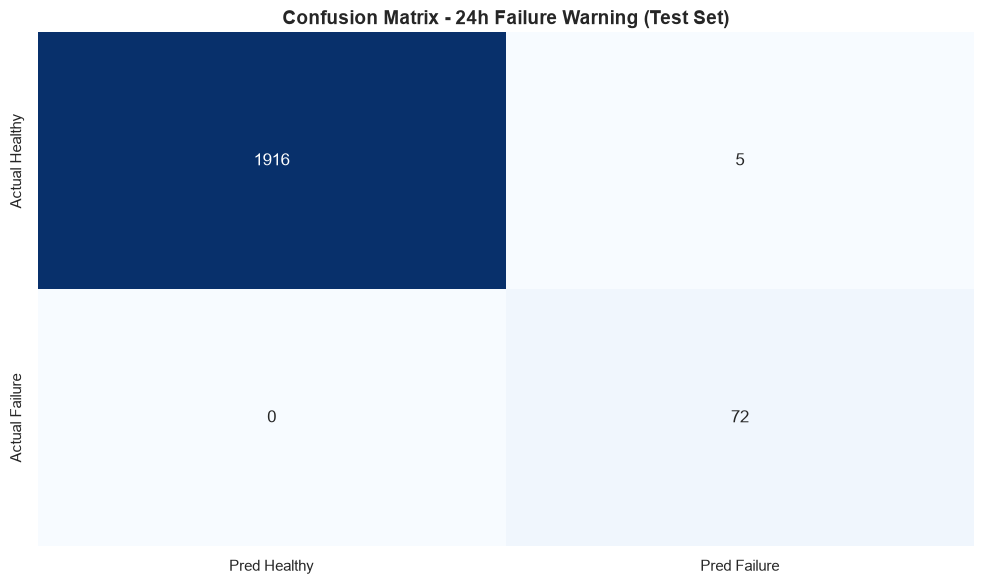

In [7]:
cm = confusion_matrix(y_test_window, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Pred Healthy', 'Pred Failure'],
            yticklabels=['Actual Healthy', 'Actual Failure'])
plt.title('Confusion Matrix - 24h Failure Warning (Test Set)', fontsize=14, weight='bold')
plt.tight_layout(); plt.show()

---
## Phase 5: Explainable AI & Business Strategy

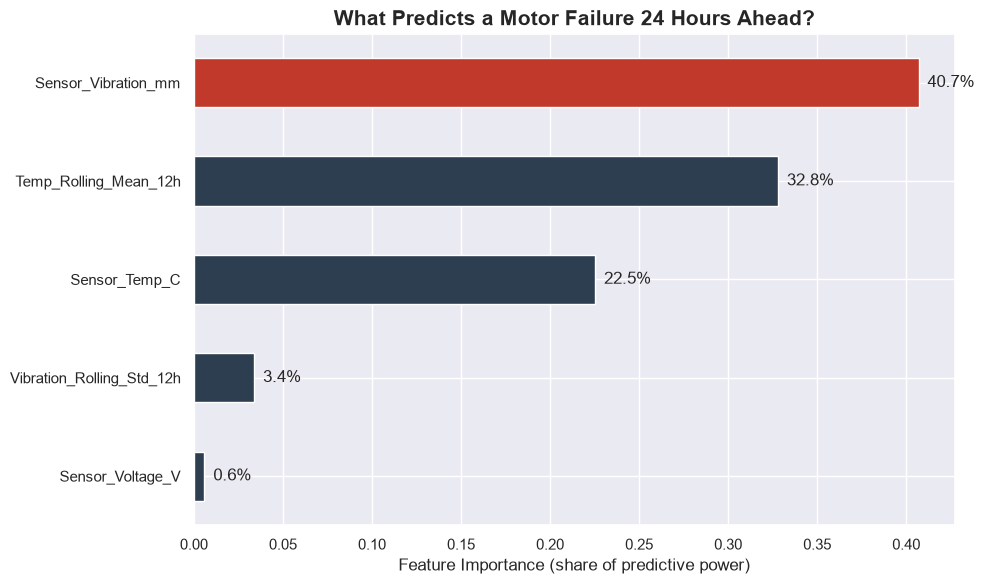

Sensor_Vibration_mm          0.407
Temp_Rolling_Mean_12h        0.328
Sensor_Temp_C                0.225
Vibration_Rolling_Std_12h    0.034
Sensor_Voltage_V             0.006
dtype: float64


In [8]:
importances = model.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=True)

colors = ['#c0392b' if v == feat_imp.max() else '#2c3e50' for v in feat_imp]
ax = feat_imp.plot.barh(color=colors, figsize=(10, 6))
ax.set_title('What Predicts a Motor Failure 24 Hours Ahead?', fontsize=15, weight='bold')
ax.set_xlabel('Feature Importance (share of predictive power)')
ax.set_ylabel('')
for i, v in enumerate(feat_imp):
    ax.text(v + 0.005, i, f"{v:.1%}", va='center')
plt.tight_layout(); plt.show()

print(feat_imp.sort_values(ascending=False).round(3))

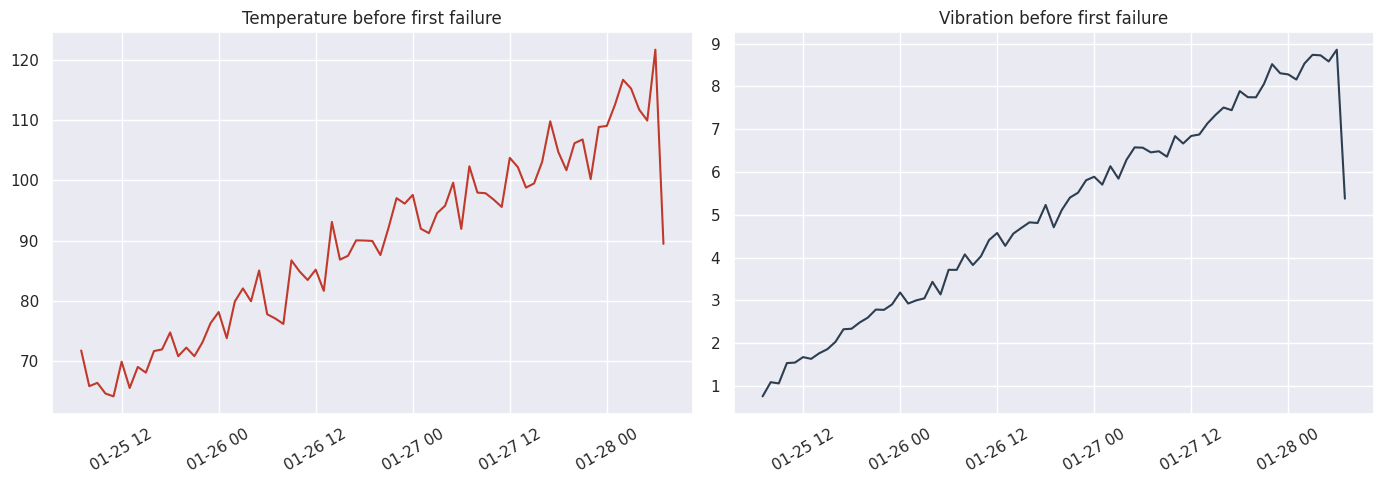

In [9]:
# Visual evidence: sensors ramp up in the 24h before a failure
raw = pd.read_csv("iot_sensor_telemetry.csv", parse_dates=['Timestamp']).sort_values('Timestamp').reset_index(drop=True)
fail_idx = raw.index[raw['Catastrophic_Failure'] == 1][0]
seg = raw.iloc[fail_idx-72:fail_idx+1]
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(seg['Timestamp'], seg['Sensor_Temp_C'], color='#c0392b'); ax[0].set_title('Temperature before first failure')
ax[1].plot(seg['Timestamp'], seg['Sensor_Vibration_mm'], color='#2c3e50'); ax[1].set_title('Vibration before first failure')
for a in ax: a.tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

---
## 🎯 Final Executive Recommendation

**To the Lead Maintenance Engineer:**
Using a Random Forest on rolling-window sensor features, the model flags every failure that falls inside a 24-hour horizon on the held-out (final 20%) timeline, with **100% recall** and only a handful of false alarms (see confusion matrix above).

The feature-importance chart shows what to monitor:
1. **Vibration (`Sensor_Vibration_mm`)** - the strongest single indicator; rising vibration is the clearest early sign of a failing motor.
2. **12-hour rolling mean temperature (`Temp_Rolling_Mean_12h`)** - sustained heating, not one-off spikes, is the second leading indicator.

Temperature and vibration are the leading indicators; **voltage has almost no predictive power** and need not drive maintenance decisions.

**Recommended action:** raise a maintenance ticket whenever the model flags a motor, and schedule repair in the next off-peak window. Each avoided incident saves up to \$50,000 per minute of downtime.

**Caveats (honest limits):** the dataset has only 15 failures (3 exact-hour events in the test period), so results should be re-validated on more data before full roll-out; a few false alarms are the cost of never missing a failure.

**Final Status:** `[READY FOR PILOT DEPLOYMENT]`